# ch213 — Optimization Landscapes

**Part VII: Calculus**

---

## 1. The Loss Surface

The **loss landscape** is the graph of the loss function over parameter space. For a model with 2 parameters, it is a surface in 3D. For millions of parameters, we cannot visualize it directly — but we can probe its properties.

Key features of the landscape:
- **Global minimum**: the lowest point overall
- **Local minima**: lower than neighbors, but not globally lowest
- **Saddle points**: a stationary point that is not a minimum in all directions *(ch214)*
- **Plateaus**: flat regions where gradient ≈ 0
- **Ridges**: narrow valleys where optimization is sensitive to direction

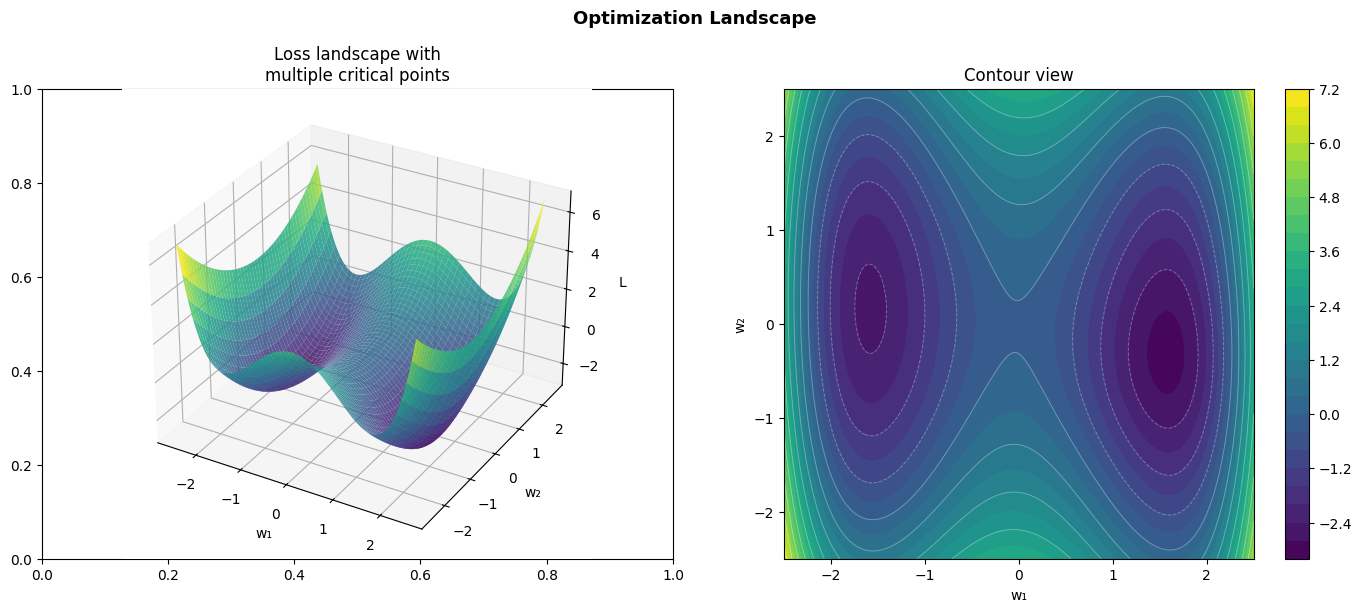

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 2D landscape with multiple features
def landscape(x, y):
    """Multiple minima, saddle points, and a global minimum."""
    return (0.4*x**4 - 2*x**2 + 0.5*y**2 + 0.1*x*y
            - 0.5*np.exp(-((x-1.5)**2 + (y+0.5)**2)))

x = np.linspace(-2.5, 2.5, 300)
y = np.linspace(-2.5, 2.5, 300)
X, Y = np.meshgrid(x, y)
Z = landscape(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 3D surface
from mpl_toolkits.mplot3d import Axes3D
ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85, linewidth=0)
ax3d.set_title('Loss landscape with\nmultiple critical points')
ax3d.set_xlabel('w₁'); ax3d.set_ylabel('w₂'); ax3d.set_zlabel('L')

# Contour view
cs = axes[1].contourf(X, Y, Z, levels=30, cmap='viridis')
axes[1].contour(X, Y, Z, levels=15, colors='white', alpha=0.3, linewidths=0.7)
plt.colorbar(cs, ax=axes[1])
axes[1].set_title('Contour view')
axes[1].set_xlabel('w₁'); axes[1].set_ylabel('w₂')
axes[1].set_aspect('equal')

plt.suptitle('Optimization Landscape', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


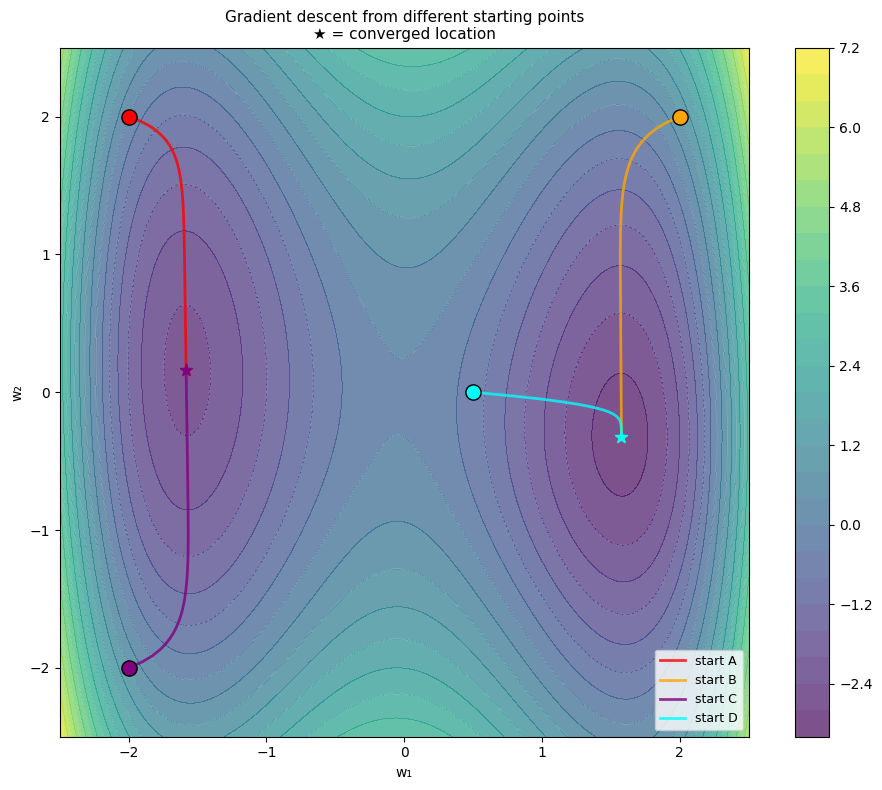

Observation: different starting points converge to DIFFERENT local minima.
This is a fundamental challenge in non-convex optimization.


In [4]:
# Simulate gradient descent from different starting points
def grad_landscape(w):
    x, y = w[0], w[1]
    dLdx = (1.6*x**3 - 4*x + 0.1*y
             + (x-1.5) * np.exp(-((x-1.5)**2 + (y+0.5)**2)))
    dLdy = (y + 0.1*x
             + (y+0.5) * np.exp(-((x-1.5)**2 + (y+0.5)**2)))
    return np.array([dLdx, dLdy])

lr = 0.02
n_steps = 500
starts = [
    (np.array([-2.0, 2.0]),  'red',    'start A'),
    (np.array([2.0, 2.0]),   'orange', 'start B'),
    (np.array([-2.0, -2.0]), 'purple', 'start C'),
    (np.array([0.5, 0.0]),   'cyan',   'start D'),
]

fig, ax = plt.subplots(figsize=(10, 8))
cs = ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
ax.contour(X, Y, Z, levels=15, colors='white', alpha=0.3, linewidths=0.7)
plt.colorbar(cs, ax=ax)

for w0, color, label in starts:
    w = w0.copy()
    path = [w.copy()]
    for _ in range(n_steps):
        g = grad_landscape(w)
        w = w - lr * g
        path.append(w.copy())
        if np.linalg.norm(g) < 1e-8:
            break
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], '-', color=color, linewidth=2, alpha=0.8, label=label)
    ax.scatter(*w0, color=color, s=120, zorder=9, edgecolors='black')
    ax.scatter(*path[-1], color=color, s=80, zorder=9, marker='*')

ax.set_title('Gradient descent from different starting points\n★ = converged location', fontsize=11)
ax.set_xlabel('w₁'); ax.set_ylabel('w₂')
ax.legend(fontsize=9)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print('Observation: different starting points converge to DIFFERENT local minima.')
print('This is a fundamental challenge in non-convex optimization.')


## 2. Convex vs Non-Convex

A function is **convex** if the line segment between any two points on its graph lies above or on the graph:

$$f(\lambda a + (1-\lambda)b) \leq \lambda f(a) + (1-\lambda)f(b) \quad \forall \lambda \in [0,1]$$

For convex functions:
- Every local minimum is a global minimum
- Gradient descent is guaranteed to find the global optimum (with appropriate lr)

Neural networks are **non-convex**. They have many local minima and saddle points. In practice, this is often acceptable — many local minima of deep networks are nearly as good as the global minimum.

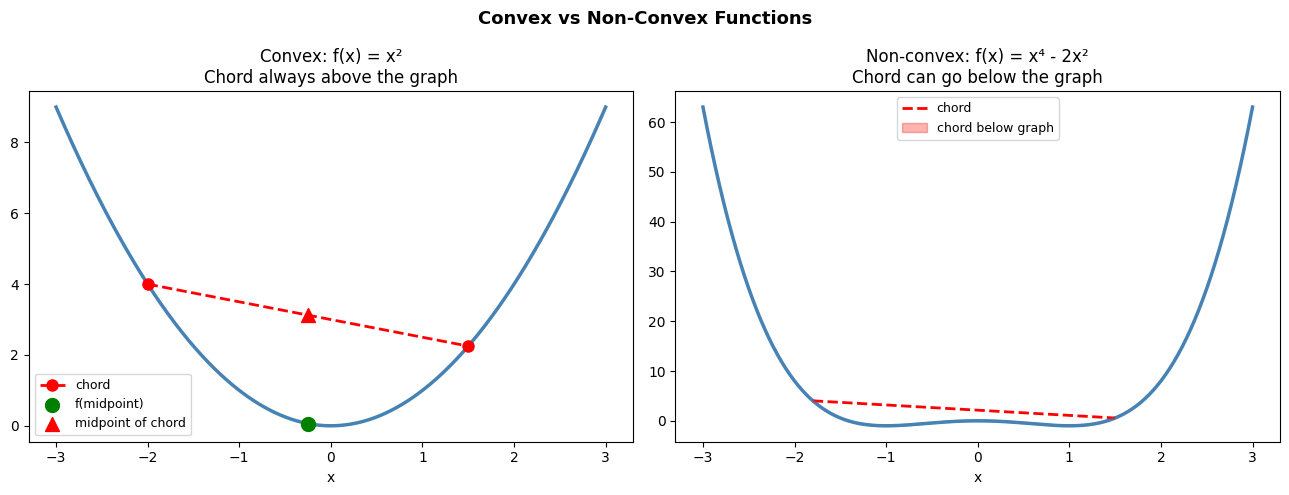

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.linspace(-3, 3, 400)

# Convex: x^2
axes[0].plot(x, x**2, color='steelblue', linewidth=2.5)
x1, x2 = -2.0, 1.5
y1, y2 = x1**2, x2**2
xm = 0.5*x1 + 0.5*x2
ym = 0.5*y1 + 0.5*y2
axes[0].plot([x1, x2], [y1, y2], 'o--', color='red', linewidth=2, markersize=8, label='chord')
axes[0].scatter([xm], [xm**2], color='green', s=100, zorder=8, label='f(midpoint)')
axes[0].scatter([xm], [ym], color='red', s=100, zorder=8, marker='^', label='midpoint of chord')
axes[0].set_title('Convex: f(x) = x²\nChord always above the graph')
axes[0].legend(fontsize=9)
axes[0].set_xlabel('x')

# Non-convex: x^4 - 2x^2
fnc = lambda x: x**4 - 2*x**2
axes[1].plot(x, fnc(x), color='steelblue', linewidth=2.5)
x1, x2 = -1.8, 1.5
y1, y2 = fnc(x1), fnc(x2)
xm = 0.5*x1 + 0.5*x2
ym = 0.5*y1 + 0.5*y2
x_chord = np.linspace(x1, x2, 100)
y_chord = y1 + (y2-y1)/(x2-x1) * (x_chord - x1)
axes[1].plot(x_chord, y_chord, '--', color='red', linewidth=2, label='chord')
axes[1].plot(x_chord, fnc(x_chord), color='steelblue', linewidth=2, alpha=0.4)
axes[1].fill_between(x_chord, fnc(x_chord), y_chord,
                     where=y_chord < fnc(x_chord), color='red', alpha=0.3, label='chord below graph')
axes[1].set_title('Non-convex: f(x) = x⁴ - 2x²\nChord can go below the graph')
axes[1].legend(fontsize=9)
axes[1].set_xlabel('x')

plt.suptitle('Convex vs Non-Convex Functions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Summary

- Loss landscapes contain minima, saddle points, and plateaus
- Gradient descent is sensitive to initialization — different starts can find different local minima
- Convex functions: local minimum = global minimum, gradient descent guaranteed to converge
- Non-convex functions (neural networks): many local minima, but many are practically good
- The geometry of the landscape (curvature) is captured by the Hessian *(ch217)*

---

## 4. Forward References

Saddle points — stationary points that are not minima — are the specific subject of ch214 — Saddle Points. The curvature of the landscape (how flat or sharp are the minima) is analyzed using second derivatives in ch217 — Second Derivatives. The full training loop that navigates this landscape is ch227 — Gradient-Based Learning.